# Figure 5 addendum: intra-experimenter session-date decoding

Plot the mean trace-level date-decoding accuracy for each experimenter. Each point is one unique train/test date-field comparison, averaged across repeated random seeds. Black markers show the experimenter mean ± std across comparisons.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

from all_gcl_manuscript import style
from all_gcl_manuscript.paths import REPO_DIR

style.set_rc_params()

In [2]:
RESULTS_FILE = Path(REPO_DIR) / "results" / (
    "session_date_binary_exp_num_1_match_experimenter-age_diff_le_10w-"
    "sex_unmatched-field_dist_unmatched_field_ids_0-1_"
    "features_chirp_8Hz_average_norm_preproc_bar.csv"
)
FIG_DIR = Path(REPO_DIR) / "figures"
FIG_DIR.mkdir(exist_ok=True)

if not RESULTS_FILE.exists():
    raise FileNotFoundError(RESULTS_FILE)

## Prepare comparison-level accuracies

In [6]:
comparison_id_cols = ["experimenter", "date_a", "date_b", "train_field_id", "test_field_id"]
required_cols = [*comparison_id_cols, "age_week_a", "age_week_b", "test_accuracy_cell"]

intra_experimenter_results = pd.read_csv(RESULTS_FILE, usecols=required_cols)
numeric_cols = ["age_week_a", "age_week_b", "test_accuracy_cell"]
intra_experimenter_results[numeric_cols] = intra_experimenter_results[numeric_cols].apply(
    pd.to_numeric,
    errors="raise",
)

# Keep comparisons where both mice are at least 4 weeks old.
intra_experimenter_results = intra_experimenter_results.dropna(subset=required_cols).copy()
intra_experimenter_results = intra_experimenter_results[
    (intra_experimenter_results["age_week_a"] >= 4)
    & (intra_experimenter_results["age_week_b"] >= 4)
].copy()

# Match the LabelEncoder-based experimenter IDs used in the original Fig5 notebook.
experimenter_encoder = LabelEncoder()
experimenter_encoder.fit(intra_experimenter_results["experimenter"].sort_values().unique())
experimenter_mapping = {
    experimenter: str(experimenter_id + 1)
    for experimenter_id, experimenter in enumerate(experimenter_encoder.classes_)
}
intra_experimenter_results["experimenter_id"] = intra_experimenter_results["experimenter"].map(
    experimenter_mapping
)

comparison_results = (
    intra_experimenter_results.groupby(["experimenter_id", *comparison_id_cols], dropna=False)
    .agg(accuracy=("test_accuracy_cell", "mean"))
    .reset_index()
)
comparison_results["accuracy_pct"] = comparison_results["accuracy"] * 100.0

experimenter_summary = (
    comparison_results.groupby(["experimenter_id", "experimenter"], dropna=False)
    .agg(
        n_comparisons=("accuracy_pct", "size"),
        mean_accuracy_pct=("accuracy_pct", "mean"),
        std_accuracy_pct=("accuracy_pct", "std"),
    )
    .sort_index(level="experimenter_id", key=lambda idx: idx.astype(int))
)

experimenter_summary

,,n_comparisons,mean_accuracy_pct,std_accuracy_pct
experimenter_id,experimenter,,,
1,Arlinghaus,2,68.209869,8.036958
2,Cai,106,61.254344,11.694401
3,Debinski,14,61.173878,8.943814
4,Dyszkant,44,62.762846,13.757906
5,Gonschorek,30,63.009816,6.131999
6,Schwerd-Kleine,6,64.916029,8.714180
7,Szatko,20,55.060235,13.642024


## Plot

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

PosixPath('/home/tzenkel/GitRepos/all-GCL-manuscript/figures/Fig5_addendum_intra_experimenter_trace_accuracy.png')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

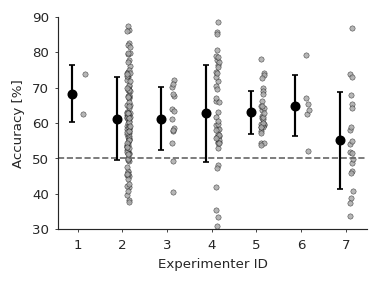

In [7]:
plot_summary = experimenter_summary.reset_index()
x_positions = np.arange(len(plot_summary), dtype=float)
rng = np.random.default_rng(42)

fig, ax = plt.subplots(figsize=(3.2, 2.4))

for x_pos, (_, row) in zip(x_positions, plot_summary.iterrows()):
    scores = comparison_results.loc[
        comparison_results["experimenter_id"] == row["experimenter_id"],
        "accuracy_pct",
    ].to_numpy(dtype=float)
    jitter = rng.uniform(-0.04, 0.04, size=len(scores)) if len(scores) > 1 else np.array([0.0])
    std = row["std_accuracy_pct"] if pd.notna(row["std_accuracy_pct"]) else 0.0

    ax.errorbar(
        [x_pos - 0.13],
        [row["mean_accuracy_pct"]],
        yerr=[[std], [std]],
        fmt="o",
        ms=5,
        color="k",
        ecolor="k",
        elinewidth=1.3,
        capsize=2,
        zorder=3,
    )
    ax.scatter(
        np.full_like(scores, x_pos + 0.13, dtype=float) + jitter,
        scores,
        color="darkgray",
        edgecolor="k",
        linewidth=0.25,
        s=10,
        alpha=0.85,
        zorder=2,
    )

ax.axhline(50, color="0.4", linestyle="--", linewidth=1)
ax.set_xlabel("Experimenter ID")
ax.set_ylabel("Accuracy [%]")
ax.set_ylim(30, 90)
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_summary["experimenter_id"])

sns.despine(fig=fig)
fig.tight_layout()

addendum_fig = FIG_DIR / "Fig5_addendum_intra_experimenter_trace_accuracy.png"
fig.savefig(addendum_fig, dpi=300, bbox_inches="tight")
addendum_fig